# 02 · Modelo baseline — Random Forest y XGBoost

**Objetivo:** un modelo clásico con features interpretables, validado **por paciente** dentro
de DS1. Es la vara con la que se va a medir la CNN: si la CNN no le gana, eso también es un
hallazgo.

**Reglas de esta fase**

- Solo DS1. **DS2 no se carga en este notebook.**
- Validación: `GroupKFold` de 5 folds con el registro como grupo.
- Pesos de clase calculados dentro de cada fold, solo con los datos de entrenamiento.
- Métricas sobre las predicciones *out-of-fold* juntas (estadística "gross" de AAMI EC57): la
  clase F vive casi entera en el registro 208, así que un F1 por fold no estaría definido.

> Proyecto educativo y de investigación. No es un dispositivo médico.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ecg import config
from ecg.evaluate import confusion, per_class_metrics, per_record_metrics, plot_confusion, summary
from ecg.features import FEATURE_SETS, build_features
from ecg.models.baseline import BaselineClassifier
from ecg.segment import load_split
from ecg.train import cross_validate, patient_folds

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
FIG_DIR = config.REPORTS_DIR / "figures"
pd.set_option("display.precision", 3)

ds1 = load_split("ds1")
y, groups, symbols = ds1["y"], ds1["record"], ds1["symbol"]
print(f"DS1: {len(y)} latidos, {len(np.unique(groups))} pacientes")

DS1: 50969 latidos, 22 pacientes


## 1. Folds por paciente

In [2]:
rows = []
for k, (tr, va) in enumerate(patient_folds(groups)):
    counts = pd.Series(y[va]).value_counts().reindex(config.CLASSES, fill_value=0)
    rows.append({"fold": k, "registros": sorted(int(r) for r in np.unique(groups[va])), **counts})
pd.DataFrame(rows).set_index("fold")

,registros,N,S,V,F
fold,,,,,
0,"[116, 119, 207, 215]",8576,110,927,1
1,"[101, 122, 209, 230]",9204,386,2,0
2,"[106, 109, 201, 203]",8155,130,1200,5
3,"[108, 112, 114, 208, 220]",9628,114,1052,378
4,"[115, 118, 124, 205, 223]",10261,203,607,30


El fold 3 contiene al registro 208 y con él 378 de los 414 latidos F. Cuando ese fold se
valida, el modelo entrena con solo **36 latidos F** de otros pacientes. El fold 1 casi no tiene V.
Esto no es un defecto de la validación: es la realidad de tener 22 pacientes.

## 2. Experimentos

In [3]:
_features = {}
results, oof = [], {}

def features(fs):
    if fs not in _features:
        _features[fs] = build_features(ds1["X"], ds1["F"], fs)
    return _features[fs][0]

def run(name, kind="xgb", feature_set="rr+morph+wave", weight_power=1.0, **params):
    t0 = time.time()
    make = lambda: BaselineClassifier(kind=kind, params=params, feature_set=feature_set,
                                      weight_power=weight_power)
    cv = cross_validate(make, features(feature_set), y, groups)
    s = summary(y, cv["pred"])
    row = {"experimento": name, "modelo": kind, "features": feature_set, "peso": weight_power,
           "params": params, "n_features": features(feature_set).shape[1], **s,
           "segundos": round(time.time() - t0)}
    results.append(row)
    oof[name] = cv
    return row

COLS = ["modelo", "features", "peso", "params", "macro_f1", "N_F1", "S_Se", "S_+P", "S_F1",
        "V_Se", "V_+P", "V_F1", "F_F1", "segundos"]

def table(names):
    return pd.DataFrame([r for r in results if r["experimento"] in names]).set_index("experimento")[COLS]

### 2.1 ¿Qué features aportan?

XGBoost con hiperparámetros por defecto y pesos balanceados. Se comparan RR solas, morfología
sola y combinaciones, y también **RR absolutos + cocientes** contra **solo cocientes**: el EDA
mostró que el RR absoluto cambia mucho entre pacientes.

In [4]:
names = []
for fs in FEATURE_SETS:
    run(f"feat:{fs}", feature_set=fs); names.append(f"feat:{fs}")
feat_table = table(names).sort_values("macro_f1", ascending=False)
best_fs = feat_table.iloc[0]["features"]
print("mejor conjunto:", best_fs)
feat_table

mejor conjunto: rr+morph+wave


,modelo,features,peso,params,macro_f1,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1,segundos
experimento,,,,,,,,,,,,,,
feat:rr+morph+wave,xgb,rr+morph+wave,1.0,{},0.493,0.947,0.319,0.445,0.372,0.914,0.509,0.654,0.000,15
feat:rr_ratios+morph,xgb,rr_ratios+morph,1.0,{},0.491,0.936,0.340,0.384,0.361,0.893,0.512,0.651,0.016,11
feat:rr+morph,xgb,rr+morph,1.0,{},0.489,0.942,0.337,0.371,0.353,0.896,0.526,0.663,0.000,12
feat:rr_ratios+morph+wave,xgb,rr_ratios+morph+wave,1.0,{},0.484,0.940,0.320,0.385,0.350,0.909,0.490,0.637,0.009,15
feat:rr_ratios,xgb,rr_ratios,1.0,{},0.394,0.882,0.293,0.054,0.092,0.617,0.582,0.599,0.003,8
feat:morph,xgb,morph,1.0,{},0.392,0.874,0.351,0.173,0.232,0.873,0.309,0.456,0.008,11
feat:rr,xgb,rr,1.0,{},0.388,0.938,0.107,0.070,0.085,0.633,0.452,0.528,0.000,9


**Conclusiones:**

- **Ritmo y morfología se complementan.** RR solas (F1 macro 0.39) y morfología sola (0.39)
  rinden igual de mal, pero juntas llegan a 0.49. Con RR solas, casi todo lo que se marca como S
  es falso (+P de S = 0.07). Con morfología sola, V pierde +P (0.31): hay latidos anchos que no
  son ventriculares.
- **Cocientes vs RR absolutos: sin diferencia medible en DS1.** `rr_ratios+morph` (0.491) y
  `rr+morph` (0.489) difieren en menos de 0.01, que es ruido con 22 pacientes (ver sección 3.1).
  La hipótesis del EDA no se confirma *dentro de DS1*, pero hay una razón: en DS1 no hay un
  paciente bradicárdico como el 232, así que la validación cruzada no puede medir ese cambio.
- **Regla de selección fijada de antemano:** el mayor F1 macro en validación cruzada. Queda
  `rr+morph+wave`. No se elige "a mano" el conjunto de cocientes por lo que se vio de DS2 en el
  EDA: eso sería usar el conjunto de prueba para decidir. Queda registrado como **riesgo a
  verificar en la Fase 5**: el modelo usa RR absolutos y el registro 232 domina los S de DS2.

### 2.2 Pesos de clase

In [5]:
names = []
for p in [0.0, 0.5, 1.0]:
    name = f"peso:{p}"
    run(name, feature_set=best_fs, weight_power=p); names.append(name)
w_table = table(names)
best_power = float(w_table.sort_values("macro_f1", ascending=False).iloc[0]["peso"])
print("mejor exponente de pesos:", best_power)
w_table

mejor exponente de pesos: 1.0


,modelo,features,peso,params,macro_f1,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1,segundos
experimento,,,,,,,,,,,,,,
peso:0.0,xgb,rr+morph+wave,0.0,{},0.481,0.950,0.240,0.431,0.308,0.908,0.527,0.667,0.0,14
peso:0.5,xgb,rr+morph+wave,0.5,{},0.484,0.950,0.262,0.419,0.322,0.911,0.522,0.664,0.0,14
peso:1.0,xgb,rr+morph+wave,1.0,{},0.493,0.947,0.319,0.445,0.372,0.914,0.509,0.654,0.0,15


**Conclusiones:**

- Los pesos balanceados completos son los mejores (F1 macro 0.481 sin pesos → 0.484 con raíz →
  0.493 balanceados). El efecto principal es en **S**: Se sube de 0.24 a 0.32 sin perder +P
  (0.43 → 0.45).
- La +P de V apenas cambia (0.53 sin pesos, 0.51 con pesos). **Los falsos V no los causan los
  pesos de clase**, ya están sin ellos. Vienen de pacientes concretos (sección 3.2).

### 2.3 Hiperparámetros de XGBoost

Grilla pequeña a propósito: con 22 pacientes, probar cientos de combinaciones termina
ajustando el ruido de la validación.

In [6]:
names = []
for depth in [3, 6]:
    for mcw in [1, 20]:
        for n_est, lr in [(300, 0.1), (600, 0.05)]:
            name = f"xgb:d{depth}_mcw{mcw}_n{n_est}"
            run(name, feature_set=best_fs, weight_power=best_power, max_depth=depth,
                min_child_weight=mcw, n_estimators=n_est, learning_rate=lr)
            names.append(name)
table(names).sort_values("macro_f1", ascending=False)

,modelo,features,peso,params,macro_f1,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1,segundos
experimento,,,,,,,,,,,,,,
xgb:d6_mcw1_n300,xgb,rr+morph+wave,1.0,"{'max_depth': 6, 'min_child_weight': 1, 'n_est...",0.493,0.947,0.319,0.445,0.372,0.914,0.509,0.654,0.000,14
xgb:d6_mcw1_n600,xgb,rr+morph+wave,1.0,"{'max_depth': 6, 'min_child_weight': 1, 'n_est...",0.489,0.946,0.309,0.432,0.360,0.913,0.503,0.649,0.002,27
xgb:d3_mcw1_n600,xgb,rr+morph+wave,1.0,"{'max_depth': 3, 'min_child_weight': 1, 'n_est...",0.489,0.940,0.378,0.378,0.378,0.911,0.491,0.638,0.000,16
xgb:d6_mcw20_n600,xgb,rr+morph+wave,1.0,"{'max_depth': 6, 'min_child_weight': 20, 'n_es...",0.488,0.943,0.350,0.376,0.362,0.914,0.499,0.646,0.000,22
xgb:d3_mcw20_n600,xgb,rr+morph+wave,1.0,"{'max_depth': 3, 'min_child_weight': 20, 'n_es...",0.485,0.938,0.375,0.359,0.367,0.913,0.487,0.635,0.000,15
xgb:d3_mcw1_n300,xgb,rr+morph+wave,1.0,"{'max_depth': 3, 'min_child_weight': 1, 'n_est...",0.483,0.939,0.378,0.351,0.364,0.913,0.477,0.627,0.002,8
xgb:d6_mcw20_n300,xgb,rr+morph+wave,1.0,"{'max_depth': 6, 'min_child_weight': 20, 'n_es...",0.482,0.942,0.343,0.353,0.348,0.914,0.489,0.637,0.000,11
xgb:d3_mcw20_n300,xgb,rr+morph+wave,1.0,"{'max_depth': 3, 'min_child_weight': 20, 'n_es...",0.480,0.936,0.374,0.339,0.356,0.914,0.479,0.628,0.000,8


### 2.4 Random Forest

In [7]:
names = []
for leaf in [1, 5, 20]:
    for depth in [None, 15]:
        name = f"rf:leaf{leaf}_d{depth}"
        run(name, kind="rf", feature_set=best_fs, weight_power=best_power,
            min_samples_leaf=leaf, max_depth=depth)
        names.append(name)
table(names).sort_values("macro_f1", ascending=False)

,modelo,features,peso,params,macro_f1,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1,segundos
experimento,,,,,,,,,,,,,,
rf:leaf5_dNone,rf,rr+morph+wave,1.0,"{'min_samples_leaf': 5, 'max_depth': None}",0.487,0.943,0.359,0.386,0.372,0.912,0.485,0.633,0.000,17
rf:leaf5_d15,rf,rr+morph+wave,1.0,"{'min_samples_leaf': 5, 'max_depth': 15}",0.486,0.942,0.365,0.380,0.372,0.912,0.482,0.631,0.000,17
rf:leaf1_d15,rf,rr+morph+wave,1.0,"{'min_samples_leaf': 1, 'max_depth': 15}",0.483,0.951,0.248,0.450,0.320,0.912,0.518,0.661,0.000,17
rf:leaf20_d15,rf,rr+morph+wave,1.0,"{'min_samples_leaf': 20, 'max_depth': 15}",0.474,0.933,0.414,0.269,0.326,0.911,0.487,0.635,0.003,16
rf:leaf20_dNone,rf,rr+morph+wave,1.0,"{'min_samples_leaf': 20, 'max_depth': None}",0.473,0.933,0.413,0.264,0.322,0.911,0.489,0.636,0.003,16
rf:leaf1_dNone,rf,rr+morph+wave,1.0,"{'min_samples_leaf': 1, 'max_depth': None}",0.469,0.951,0.193,0.402,0.261,0.912,0.520,0.663,0.000,18


**Conclusiones:**

- Las 8 configuraciones de XGBoost quedan entre 0.480 y 0.493, y las 6 de Random Forest entre
  0.469 y 0.487. **La configuración por defecto de XGBoost es la mejor.**
- Árboles menos profundos (`max_depth=3`) suben la Se de S (0.38) a costa de su +P. En RF,
  hojas de 1 muestra sobreajustan (Se de S = 0.19) y `min_samples_leaf=5` queda a la par de
  XGBoost.
- Las diferencias (≤ 0.02) son mucho menores que la variación entre folds. **Los
  hiperparámetros no son el cuello de botella: la variabilidad entre pacientes sí.**
- Tres experimentos corresponden a la misma configuración (`feat:rr+morph+wave`, `peso:1.0` y
  `xgb:d6_mcw1_n300`) y dan métricas idénticas: el entrenamiento es determinista.

### 2.5 Tabla general

In [8]:
# orden estable: ante empates gana el experimento que se corrió primero
board = (pd.DataFrame(results).set_index("experimento")
           .sort_values("macro_f1", ascending=False, kind="stable"))
board.drop(columns=["segundos"]).to_csv(config.REPORTS_DIR / "baseline_experiments.csv")
best = board.index[0]
best_row = board.loc[best]
best_label = (f"{'XGBoost' if best_row['modelo'] == 'xgb' else 'Random Forest'} · "
              f"{best_row['features']} · pesos^{best_row['peso']:g} · {best_row['params'] or 'por defecto'}")
print("elegido:", best, "|", best_label)
board[COLS].head(10)

elegido: feat:rr+morph+wave | XGBoost · rr+morph+wave · pesos^1 · por defecto


,modelo,features,peso,params,macro_f1,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,F_F1,segundos
experimento,,,,,,,,,,,,,,
feat:rr+morph+wave,xgb,rr+morph+wave,1.0,{},0.493,0.947,0.319,0.445,0.372,0.914,0.509,0.654,0.000,15
peso:1.0,xgb,rr+morph+wave,1.0,{},0.493,0.947,0.319,0.445,0.372,0.914,0.509,0.654,0.000,15
xgb:d6_mcw1_n300,xgb,rr+morph+wave,1.0,"{'max_depth': 6, 'min_child_weight': 1, 'n_est...",0.493,0.947,0.319,0.445,0.372,0.914,0.509,0.654,0.000,14
feat:rr_ratios+morph,xgb,rr_ratios+morph,1.0,{},0.491,0.936,0.340,0.384,0.361,0.893,0.512,0.651,0.016,11
feat:rr+morph,xgb,rr+morph,1.0,{},0.489,0.942,0.337,0.371,0.353,0.896,0.526,0.663,0.000,12
xgb:d6_mcw1_n600,xgb,rr+morph+wave,1.0,"{'max_depth': 6, 'min_child_weight': 1, 'n_est...",0.489,0.946,0.309,0.432,0.360,0.913,0.503,0.649,0.002,27
xgb:d3_mcw1_n600,xgb,rr+morph+wave,1.0,"{'max_depth': 3, 'min_child_weight': 1, 'n_est...",0.489,0.940,0.378,0.378,0.378,0.911,0.491,0.638,0.000,16
xgb:d6_mcw20_n600,xgb,rr+morph+wave,1.0,"{'max_depth': 6, 'min_child_weight': 20, 'n_es...",0.488,0.943,0.350,0.376,0.362,0.914,0.499,0.646,0.000,22
rf:leaf5_dNone,rf,rr+morph+wave,1.0,"{'min_samples_leaf': 5, 'max_depth': None}",0.487,0.943,0.359,0.386,0.372,0.912,0.485,0.633,0.000,17


## 3. Modelo elegido: análisis de validación

,Se,+P,F1,TP,FN,FP,n
clase,,,,,,,
N,0.916,0.980,0.947,41953,3871,863,45824
S,0.319,0.445,0.372,301,642,376,943
V,0.914,0.509,0.654,3463,325,3338,3788
F,0.000,0.000,0.000,0,414,675,414


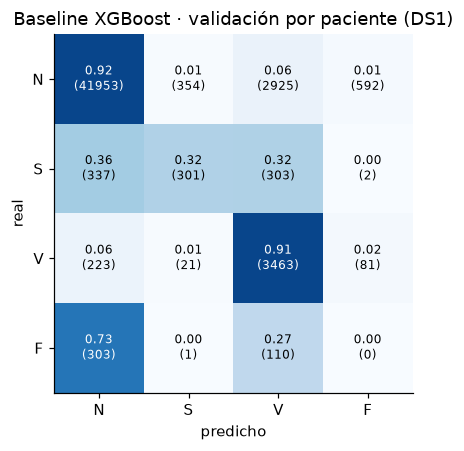

In [9]:
pred = oof[best]["pred"]
cm, cm_norm = confusion(y, pred), confusion(y, pred, normalize=True)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
plot_confusion(cm_norm, ax, "Baseline XGBoost · validación por paciente (DS1)", counts=cm)
fig.tight_layout(); fig.savefig(FIG_DIR / "baseline_confusion_cv.png")
per_class_metrics(y, pred)

In [10]:
always_n = (y == "N").mean()
print(f"exactitud del modelo: {summary(y, pred)['accuracy']:.3f}")
print(f"exactitud de predecir siempre N: {always_n:.3f}")

exactitud del modelo: 0.897
exactitud de predecir siempre N: 0.899


### 3.1 Variabilidad entre folds

In [11]:
rows = []
for k in range(5):
    m = oof[best]["fold"] == k
    pc = per_class_metrics(y[m], pred[m])
    rows.append({"fold": k, **{f"{c}_{met}": pc.loc[c, met] for c in ["S", "V", "F"]
                               for met in ["n", "Se", "+P"]}})
pd.DataFrame(rows).set_index("fold")

,S_n,S_Se,S_+P,V_n,V_Se,V_+P,F_n,F_Se,F_+P
fold,,,,,,,,,
0,110,0.027,0.107,927,0.822,0.336,1,0.0,0.0
1,386,0.381,0.919,2,1.000,1.000,0,NaN,NaN
2,130,0.246,0.101,1200,0.989,0.447,5,0.0,0.0
3,114,0.719,0.656,1052,0.995,0.799,378,0.0,NaN
4,203,0.182,0.787,607,0.766,0.826,30,0.0,0.0


**Conclusiones:**

- **La exactitud del modelo (0.897) es menor que la de predecir siempre N (0.899).** Aun así, el
  modelo detecta el 91 % de los V, mientras que "siempre N" detecta el 0 %. Por eso la exactitud
  no es la métrica principal.
- La variabilidad entre folds es enorme: la Se de S va de **0.03 (fold 0) a 0.72 (fold 3)** y
  la +P de V de **0.34 a 0.83**. El número agregado (F1 macro 0.49) esconde ese rango. Con 22
  pacientes, diferencias de 0.01 entre configuraciones no significan nada.
- **F nunca se detecta** (Se = 0 en todos los folds). Cuando se valida el 208, el modelo
  entrenó con 36 latidos F. Esto confirma lo que anticipó el EDA.

### 3.2 ¿En qué pacientes falla?

In [12]:
pr = per_record_metrics(y, pred, groups)
for a, b in [("N", "V"), ("N", "S"), ("S", "N"), ("V", "N"), ("F", "N")]:
    pr[f"{a}→{b}"] = pd.Series(pd.DataFrame({"r": groups, "e": (y == a) & (pred == b)})
                                 .groupby("r").e.sum())
pr.sort_values("errores", ascending=False).head(8)

,latidos,errores,n_N,n_S,n_V,n_F,Se_S,+P_S,Se_V,+P_V,Se_F,+P_F,N→V,N→S,S→N,V→N,F→N
record,,,,,,,,,,,,,,,,,
203,2974,1770,2527,2,444,1,0.000,0.000,0.993,0.250,0.0,0.0,1320,39,0,0,0
207,1858,1517,1542,106,210,0,0.000,0.000,0.948,0.117,NaN,0.0,1400,0,1,4,0
201,1961,496,1633,128,198,2,0.250,0.118,0.995,0.670,0.0,0.0,3,240,0,1,2
208,2951,388,1585,2,992,372,0.000,0.000,0.999,0.904,0.0,NaN,1,12,2,1,267
209,3003,249,2619,383,1,0,0.381,0.924,1.000,1.000,NaN,NaN,0,12,237,0,0
215,3361,172,3193,3,164,1,1.000,0.143,0.073,0.857,0.0,0.0,2,17,0,149,1
223,2603,165,2043,73,473,14,0.479,0.946,0.767,0.989,0.0,0.0,0,1,35,31,13
108,1761,158,1738,4,17,2,0.000,0.000,0.765,0.079,0.0,NaN,148,0,0,1,2


In [13]:
err = pd.DataFrame({"registro": groups, "símbolo": symbols, "real": y, "pred": pred})
by_symbol = (err.assign(acierto=err.real == err.pred)
                .groupby(["real", "símbolo"]).acierto.agg(["size", "mean"])
                .rename(columns={"size": "latidos", "mean": "Se"}))
by_symbol

latidos     Se
real símbolo                
F    F            414  0.000
N    L           3947  0.626
     N          38067  0.937
     R           3778  0.999
     e             16  0.938
     j             16  1.000
S    A            809  0.365
     J             32  0.031
     S              2  0.000
     a            100  0.050
V    E            105  0.962
     V           3683  0.913

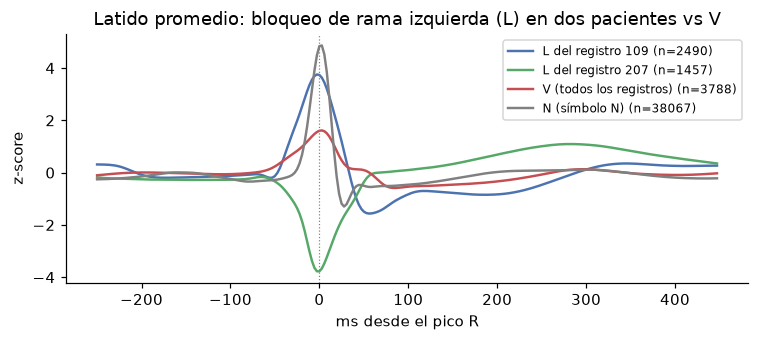

In [14]:
t_ms = (np.arange(config.WINDOW) - config.PRE_SAMPLES) / config.FS * 1000
fig, ax = plt.subplots(figsize=(7, 3.2))
for label, m, color in [
    ("L del registro 109", (symbols == "L") & (groups == 109), "#4C72B0"),
    ("L del registro 207", (symbols == "L") & (groups == 207), "#55A868"),
    ("V (todos los registros)", y == "V", "#C44E52"),
    ("N (símbolo N)", symbols == "N", "grey"),
]:
    ax.plot(t_ms, ds1["X"][m].mean(0), color=color, lw=1.6, label=f"{label} (n={m.sum()})")
ax.axvline(0, color="grey", ls=":", lw=0.8)
ax.set_xlabel("ms desde el pico R"); ax.set_ylabel("z-score"); ax.legend(fontsize=8)
ax.set_title("Latido promedio: bloqueo de rama izquierda (L) en dos pacientes vs V")
fig.tight_layout(); fig.savefig(FIG_DIR / "lbbb_207_vs_109.png")

Los grupos de errores más grandes, cruzados con las **anotaciones de ritmo** de MIT-BIH
(`(N`, `(AFIB`, `(AFL`, `(SVTA`, …):

In [15]:
from ecg.data import rhythm_at

rows = []
for rec, real, predicho in [(207, "N", "V"), (203, "N", "V"), (201, "N", "S"), (209, "S", "N"),
                            (208, "F", "N"), (215, "V", "N")]:
    m = (groups == rec) & (y == real) & (pred == predicho)
    rh = pd.Series(rhythm_at(rec, ds1["r_peak"][m])).value_counts()
    sym = pd.Series(symbols[m]).value_counts()
    rows.append({"registro": rec, "error": f"{real}→{predicho}", "latidos": int(m.sum()),
                 "símbolos": sym.to_dict(), "ritmo": rh.to_dict()})
pd.DataFrame(rows).set_index("registro")

,error,latidos,símbolos,ritmo
registro,,,,
207,N→V,1400,"{'L': 1399, 'R': 1}","{'(N': 1396, '(B': 4}"
203,N→V,1320,{'N': 1320},"{'(AFIB': 1114, '(AFL': 205, '(T': 1}"
201,N→S,240,{'N': 240},"{'(AFIB': 221, '(N': 18, '(NOD': 1}"
209,S→N,237,{'A': 237},"{'(SVTA': 201, '(N': 36}"
208,F→N,267,{'F': 267},"{'(N': 262, '(T': 5}"
215,V→N,149,{'V': 149},"{'(N': 144, '(VT': 5}"


In [16]:
m = (groups == 209) & (y == "S")
s209 = pd.DataFrame({"ritmo": rhythm_at(209, ds1["r_peak"][m]), "detectado": pred[m] == "S",
                     "RR previo / RR local": ds1["F"][m, 2]})
s209.groupby("ritmo").agg(latidos=("detectado", "size"), Se=("detectado", "mean"),
                          cociente_mediana=("RR previo / RR local", "median"))

,latidos,Se,cociente_mediana
ritmo,,,
(N,124,0.710,0.798
(SVTA,259,0.224,0.971


**Conclusiones: cuatro modos de falla con explicación fisiológica**

1. **Bloqueo de rama izquierda con otra polaridad (207, 1 399 L→V).** El LBBB del 207 tiene el
   QRS *invertido* en MLII y el del 109 es positivo. El modelo aprendió "LBBB = QRS ancho
   positivo" de un solo paciente. La clase N de AAMI mezcla morfologías muy distintas (N, L, R),
   y con 1–2 pacientes por morfología no hay forma de generalizar. **DS2 tiene latidos L en los
   registros 111 y 214: es un riesgo concreto para la Fase 5.**
2. **Fibrilación/flutter auricular + ruido (203, 1 320 N→V).** Casi todos ocurren durante
   `(AFIB` o `(AFL`, en el registro más ruidoso del EDA. RR irregular, morfología aberrante y
   ruido a la vez.
3. **Fibrilación auricular (201, 240 N→S).** Durante una FA el RR es irregular por naturaleza,
   así que latidos conducidos normalmente *parecen* prematuros. Las features RR suponen un ritmo
   de base regular.
4. **Rachas de taquicardia supraventricular (209, 237 S→N).** Dentro de una SVTA el "RR local"
   (promedio de los 10 latidos previos) también es corto, entonces RR previo / RR local ≈ 0.97 y
   el latido prematuro deja de parecerlo: Se de S = 0.22 en SVTA vs 0.71 en ritmo normal. **Es
   una limitación estructural del feature**, no del clasificador. Una referencia de RR más
   larga o robusta es un experimento candidato.

Además: F→N en 208 (sin datos de F para aprender) y V→N en 215 (149 latidos). V→N es el error
más grave del análisis de riesgo (RISK-01): 223 de 3 788 latidos V (5.9 %), dos tercios en un
solo paciente.

### 3.3 Importancia de features

kurtosis            0.144
wave_+433ms         0.100
pre_rr              0.074
qrs_max             0.069
post_rr             0.055
post_over_pre_rr    0.049
qrs_min             0.047
qrs_argmin_ms       0.036
t_max               0.034
r_amp               0.034
dtype: float32

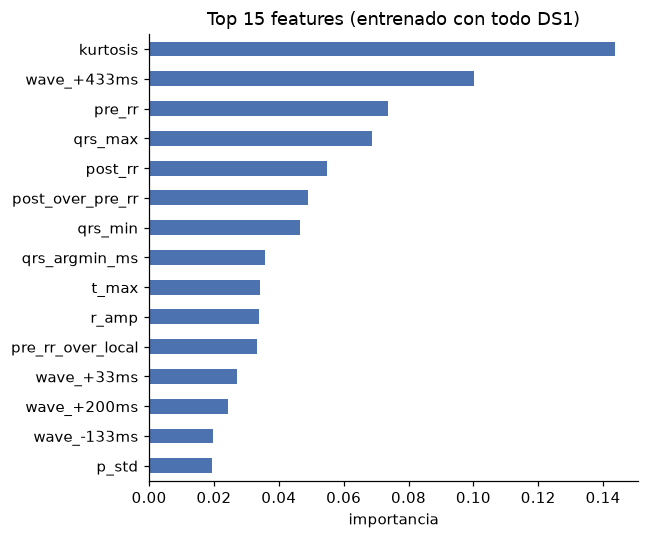

In [17]:
kind, fs, pw, params = best_row["modelo"], best_row["features"], best_row["peso"], best_row["params"]
Z, feat_names = build_features(ds1["X"], ds1["F"], fs)
full = BaselineClassifier(kind=kind, params=params, feature_set=fs, weight_power=pw).fit(Z, y)
imp = pd.Series(full.feature_importances(), index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(6, 5))
imp.tail(15).plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Top 15 features (entrenado con todo DS1)"); ax.set_xlabel("importancia")
fig.tight_layout(); fig.savefig(FIG_DIR / "baseline_feature_importance.png")
imp.sort_values(ascending=False).head(10)

**Conclusiones:**

- **Curtosis** es la feature más usada: separa un QRS angosto y puntiagudo (N, S) de uno ancho
  (V).
- **`wave_+433ms`** (el final de la ventana) es la segunda. Si el siguiente latido llega antes
  de 450 ms, ese bin sube: es información de *ritmo* que se cuela en la ventana de morfología.
  La CNN va a poder aprovechar lo mismo.
- **`pre_rr` y `post_rr` absolutos están en el top 5.** El modelo depende del RR absoluto, que
  el EDA mostró que cambia en pacientes bradicárdicos. Esto refuerza el riesgo del registro 232
  en DS2.

In [18]:
# Reproducibilidad: misma semilla, mismas predicciones
again = cross_validate(lambda: BaselineClassifier(kind=kind, params=params, feature_set=fs,
                                                 weight_power=pw), Z, y, groups)
print("predicciones idénticas:", np.array_equal(again["pred"], pred))

predicciones idénticas: True


## Resumen

**Baseline elegido:** XGBoost (hiperparámetros por defecto) · 41 features
(`rr+morph+wave`) · pesos de clase balanceados. Entrenar el modelo final:
`python -m ecg.train baseline`.

| Clase | Se | +P | F1 |
|---|---|---|---|
| N | 0.916 | 0.980 | 0.947 |
| S | 0.319 | 0.445 | 0.372 |
| V | 0.914 | 0.509 | 0.654 |
| F | 0.000 | 0.000 | 0.000 |
| **F1 macro** | | | **0.493** |

*Validación cruzada de 5 folds por paciente en DS1. No es el resultado final: ese sale de DS2,
una sola vez, en la Fase 5.*

**Qué tiene que mejorar la CNN (Fase 4):**

| Problema | Evidencia | Idea a probar |
|---|---|---|
| V con +P baja (0.51) | L→V en 207, N→V en FA del 203 | Aprender la morfología completa en vez de features resumidas; aumento de datos con inversión de amplitud |
| S con Se baja (0.32) | S→N dentro de SVTA (209), N→S en FA (201) | Features RR en la cabeza de la red; referencia de RR más robusta |
| F no detectada | 1 paciente con F por split | Probablemente no se resuelve con datos de MIT-BIH: documentar como limitación |
| Riesgo en DS2 por RR absoluto | `pre_rr`/`post_rr` en el top 5; 232 bradicárdico | Comparar con solo cocientes, decidiendo con validación en DS1 |